In [1]:
import torch
from utils import solve_riccati
import numpy as np
from network import PhiNetwork, ScoreNetwork
from utils import batched_jacobian
import matplotlib.pyplot as plt

In [2]:
phi_net = ScoreNetwork(input_dim=2+1, out_dim=2, hidden_dim=32)
phi_net.load_state_dict(torch.load('data/phi_network_ip_bsde_nl0.5.pth'))

/var/folders/pd/hp6m3j2j5v9bd6w64h7wl3rm0000gn/T/ipykernel_42828/2101403717.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  phi_net.load_state_dict(torch.load('data/phi_

<All keys matched successfully>

In [15]:
T = 4.0  # End time
n = 2    # Dimension of state space
m = 1    # Dimension of Brownian motion
N = 10000 # Number of training samples
dt = 0.05
steps = int(T/dt)
noise_level = 0.5

In [4]:
def f(x):
    """
    Drift function of X_t for a nonlinear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Drift vector. Shape (N, n)
    """
    df1 = x[:, 1]
    df2 = torch.sin(x[:, 0]) - 0.01 * x[:, 1]
    df = torch.stack((df1, df2), dim=1)
    return df


def g(x):
    """
    Diffusion function of X_t for a nonlinear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Diffusion matrix. Shape (N, n, m)
    """
    B = torch.tensor([[0.0], [1.0]]) * noise_level
    B = B.unsqueeze(0).repeat(x.shape[0], 1, 1)
    return B

def lf(x):
    """
    Terminal cost function for a linear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Terminal cost. Shape (N,)
    """
    # Q_f = torch.tensor([[1.0, 0.0], [0.0, 1.0]])
    # return 0.5 * ((x @ Q_f) * x).sum(dim=1)
    return 0.5 * x[:,1] * x[:,1] + 1 - torch.cos(x[:,0])

In [12]:
from utils import rollout, noise

In [13]:
W_f = torch.zeros((steps+1, N, m))# forward noise
# W_b = torch.zeros((steps+1, N, m))# backward noise
for noise_step in range(steps+1):
    W_f[noise_step, :, :] = noise(dt, N, m)

iteration    0 | autograd loss 2.45012 | phi loss 2.45012
iteration 1000 | autograd loss 2.19305 | phi loss 1.81045
iteration 2000 | autograd loss 2.02814 | phi loss 1.56582
iteration 3000 | autograd loss 1.94671 | phi loss 1.50513
iteration 4000 | autograd loss 1.90935 | phi loss 1.51417
iteration 5000 | autograd loss 1.82019 | phi loss 1.48618
iteration 6000 | autograd loss 1.79202 | phi loss 1.49947
iteration 7000 | autograd loss 1.76429 | phi loss 1.49057
iteration 8000 | autograd loss 1.727 | phi loss 1.49642
iteration 9000 | autograd loss 1.68168 | phi loss 1.48932

Final:
autograd: loss=1.66391
phi     : loss=1.48001


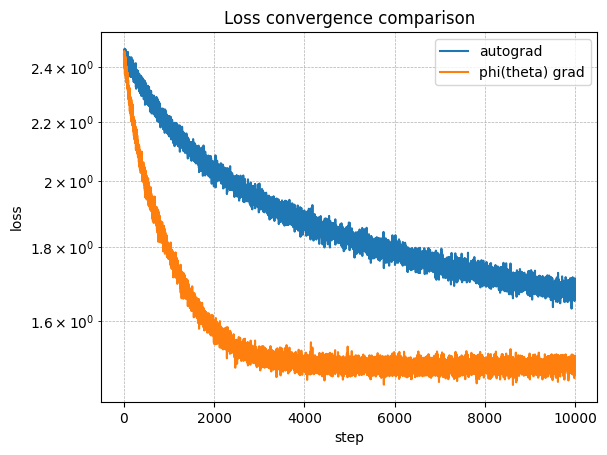

In [22]:
theta0 = torch.randn((N, n))

theta_auto = theta0.clone().detach().requires_grad_(True)
theta_phi  = theta0.clone().detach().requires_grad_(True)  # requires_grad can stay True; we won't call backward()

opt_auto = torch.optim.Adam([theta_auto], lr=1e-3)
opt_phi  = torch.optim.Adam([theta_phi],  lr=1e-3)

loss_hist_auto = []
loss_hist_phi  = []
for i in range(10000):
    W_f = torch.zeros((steps+1, N, m))# forward noise

    for noise_step in range(steps+1):
        W_f[noise_step, :, :] = noise(dt, N, m)
    # ======== Method A: autograd ========
    opt_auto.zero_grad(set_to_none=True)

    # compute loss (keep exactly same code path)
    xT_auto = rollout(f, g, T, dt, theta_auto, W_f)[-1]
    loss_auto = lf(xT_auto).mean(dim=0)  # your original loss
    loss_auto.backward()
    opt_auto.step()

    # ======== Method B: custom phi gradient ========
    opt_phi.zero_grad(set_to_none=True)

    # compute loss for logging only (optional but useful)
    # If rollout is expensive and you only care about update, you can skip this forward.
    with torch.no_grad():
        xT_phi = rollout(f, g, T, dt, theta_phi, W_f)[-1]
        loss_phi = lf(xT_phi).mean(dim=0)

    # apply your gradient estimator
    # IMPORTANT: optimizer expects theta_phi.grad to be a tensor on same device/dtype
    with torch.no_grad():
        ghat = phi_net(theta_phi, torch.tensor(0.0).repeat(theta_phi.shape[0], 1))  # shape (N, n)
        theta_phi.grad = ghat.detach()
    opt_phi.step()

    # ---- log ----
    loss_hist_auto.append(loss_auto.detach().item() if loss_auto.numel()==1 else loss_auto.detach().mean().item())
    loss_hist_phi.append(loss_phi.detach().item()  if loss_phi.numel()==1  else loss_phi.detach().mean().item())

    # optional: print occasionally
    if i % max(1, 10000 // 10) == 0:
        print(f"iteration {i:4d} | autograd loss {loss_hist_auto[-1]:.6g} | phi loss {loss_hist_phi[-1]:.6g}")

# ---- final report ----
print("\nFinal:")
print(f"autograd: loss={loss_hist_auto[-1]:.6g}")
print(f"phi     : loss={loss_hist_phi[-1]:.6g}")

# ---- plot ----
plt.figure()
plt.plot(loss_hist_auto, label="autograd")
plt.plot(loss_hist_phi,  label="phi(theta) grad")
plt.yscale("log")  # often helpful; remove if you prefer linear
plt.xlabel("step")
plt.ylabel("loss")
plt.title("Loss convergence comparison")
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()

Text(0.5, 1.0, 'Optimal theta comparison')

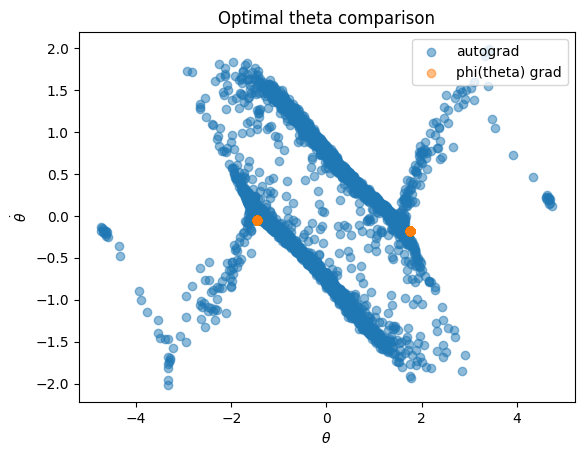

In [26]:
## plot of optimal theta
plt.figure()
plt.scatter(theta_auto.detach().numpy()[:,0], theta_auto.detach().numpy()[:,1], label="autograd", alpha=0.5)
plt.scatter(theta_phi.detach().numpy()[:,0], theta_phi.detach().numpy()[:,1], label="phi(theta) grad", alpha=0.5)
plt.xlabel(r"$\theta$")
plt.ylabel(r"$\dot{\theta}$")
plt.legend()
plt.title("Optimal theta comparison")

In [27]:
theta_phi.detach().mean(dim=0), theta_auto.detach().mean(dim=0)

(tensor([ 0.1130, -0.1164]), tensor([-0.0261,  0.0045]))

In [28]:
theta_phi.detach().std(dim=0), theta_auto.detach().std(dim=0)

(tensor([1.6112, 0.0626]), tensor([1.3940, 0.4797]))

In [31]:
randindex = np.random.randint(0, theta_phi.shape[0], size=50) # generate 50 random index
theta_phi.detach()[randindex,0]

tensor([ 1.7587, -1.4644,  1.7587,  1.7587, -1.4644, -1.4644, -1.4644, -1.4644,
        -1.4644, -1.4644, -1.4644, -1.4644,  1.7587,  1.7587,  1.7587, -1.4644,
         1.7587,  1.7587, -1.4644, -1.4644,  1.7587, -1.4644, -1.4644,  1.7587,
         1.7587, -1.4644,  1.7587, -1.4644, -1.4644,  1.7587,  1.7587, -1.4644,
        -1.4644,  1.7587,  1.7587, -1.4644,  1.7587,  1.7587,  1.7587,  1.7587,
        -1.4644,  1.7587, -1.4644,  1.7587, -1.4644, -1.4644, -1.4644, -1.4644,
        -1.4644,  1.7587])

In [32]:
final_traj_phi = rollout(f, g, T, dt, theta_phi, W_f)
final_traj_auto = rollout(f, g, T, dt, theta_auto, W_f)

In [33]:
final_traj_phi.shape

torch.Size([81, 10000, 2])

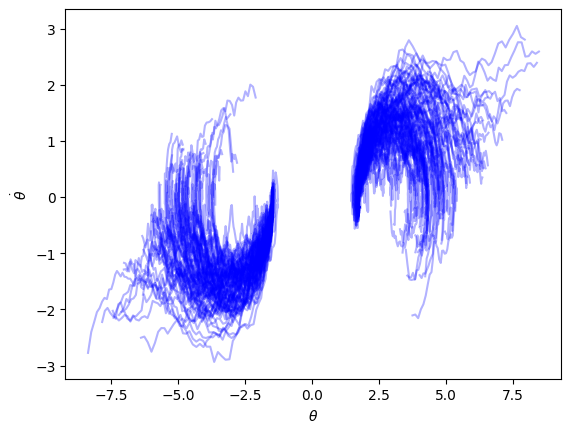

In [39]:
plt.figure()
for sample_idx in range(200):
    plt.plot(final_traj_phi[:, sample_idx, 0].detach().numpy(), final_traj_phi[:, sample_idx, 1].detach().numpy(), color='blue', alpha=0.3)
    # plt.plot(final_traj_auto[:, sample_idx, 0].detach().numpy(), final_traj_auto[:, sample_idx, 1].detach().numpy(), color='orange', alpha=0.3)
plt.xlabel(r"$\theta$")
plt.ylabel(r"$\dot{\theta}$")
# plt.title("Sample trajectories with phi(theta) grad")
plt.show()